In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import json
from datetime import datetime
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Loading Data

In [12]:
# files = ["preprocessed_data_1.json", "preprocessed_data_2.json", "preprocessed_data_3.json"]
files = ["preprocessed_data_modified.json"]
data = []
for file in files:
    with open(file, "r", encoding="utf-8") as f:
        data += [pd.DataFrame(json.load(f))]

df = pd.concat(data, ignore_index=True)
print(df.head())
print(len(df))

             start station            end station  hour  minute  week day  \
0  Công ty Bông Bạch Tuyết  Vòng xoay Lê Đại Hành     5      21         6   
1    Vòng xoay Lê Đại Hành                Parkson     5      25         6   
2                  Parkson      Siêu thị Coormark     6      32         6   
3        Siêu thị Coormark          Chợ Tân Phước     6      33         6   
4            Chợ Tân Phước   Ngã tư Lạc Long Quân     6      35         6   

   week end  distance (m)  duration (s)  
0         1   1523.383736           220  
1         1    876.796880          3992  
2         1    686.882991           100  
3         1    489.097757            88  
4         1    340.790582            50  
122537


# Preprocessing

In [13]:
# Con số 3000 ở đây là theo quy định pháp luật
# uyến xe buýt có các điểm dừng đón, trả khách. Khoảng cách tối đa giữa hai điểm dừng đón, 
# trả khách liền kề trong nội thành, nội thị là 700 mét, ngoại thành, ngoại thị là 3.000 mét.
# 3000 ở đây là worst case
df = df[(df["distance (m)"] <= 3000) & (df["duration (s)"] <= 1800)]
print(len(df))

82983


In [14]:
df["route"] = df["start station"] + "_" + df["end station"]
route_mean = (
    df.groupby("route")["duration (s)"]
      .mean()
      .rename("route_avg_duration")
)
df = df.merge(route_mean, on="route")
df = df.drop(columns=["route"])
# df = df.drop(columns=["start station"])
# df = df.drop(columns=["end station"])

print(df.head(5))
print(len(df))

df.to_json("dataset.json", orient="records", force_ascii=False, indent=4)

             start station            end station  hour  minute  week day  \
0  Công ty Bông Bạch Tuyết  Vòng xoay Lê Đại Hành     5      21         6   
1                  Parkson      Siêu thị Coormark     6      32         6   
2        Siêu thị Coormark          Chợ Tân Phước     6      33         6   
3            Chợ Tân Phước   Ngã tư Lạc Long Quân     6      35         6   
4     Ngã tư Lạc Long Quân           Ngã 3 Ba Vân     6      35         6   

   week end  distance (m)  duration (s)  route_avg_duration  
0         1   1523.383736           220          296.400000  
1         1    686.882991           100           96.000000  
2         1    489.097757            88          106.000000  
3         1    340.790582            50          109.631579  
4         1   2615.816305           472          657.250000  
82983


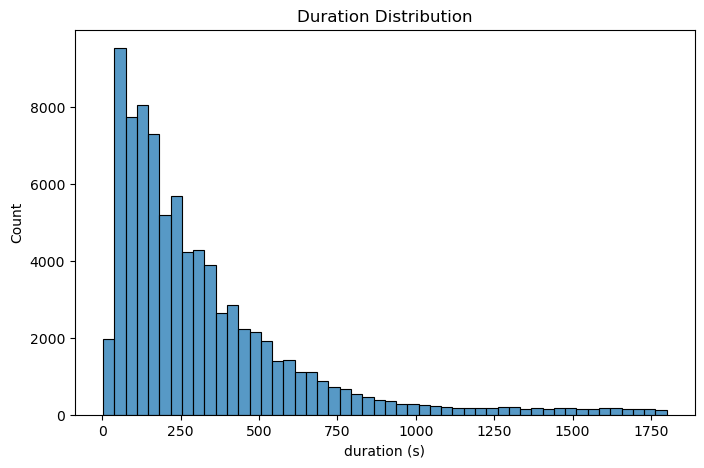

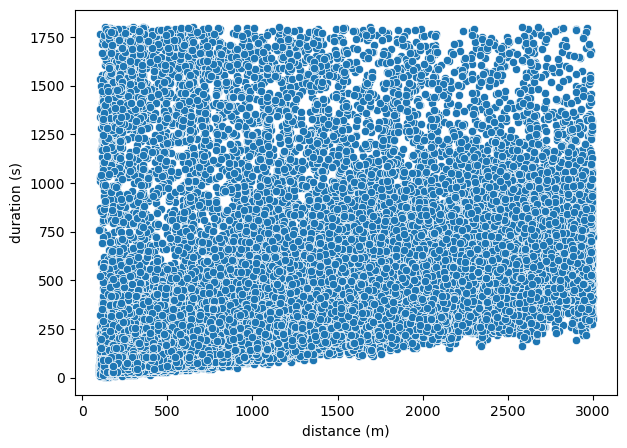

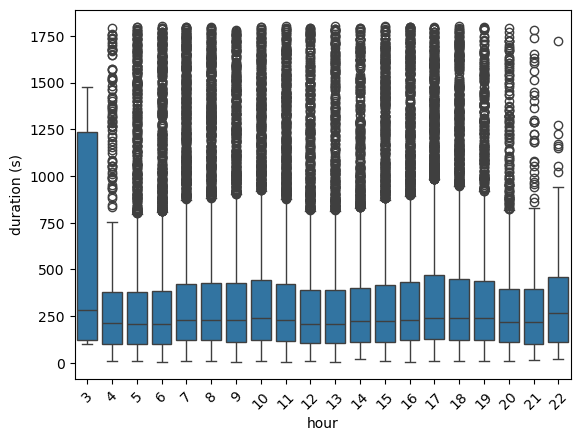

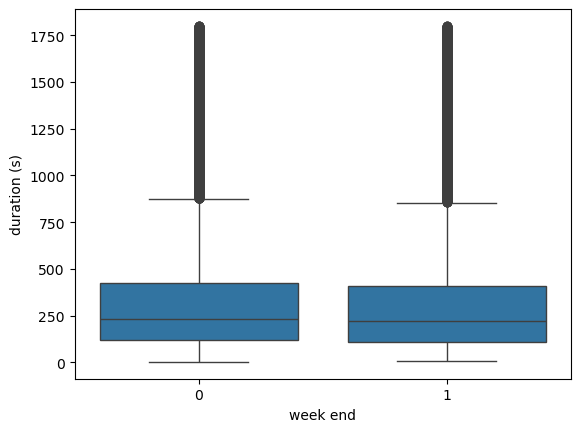

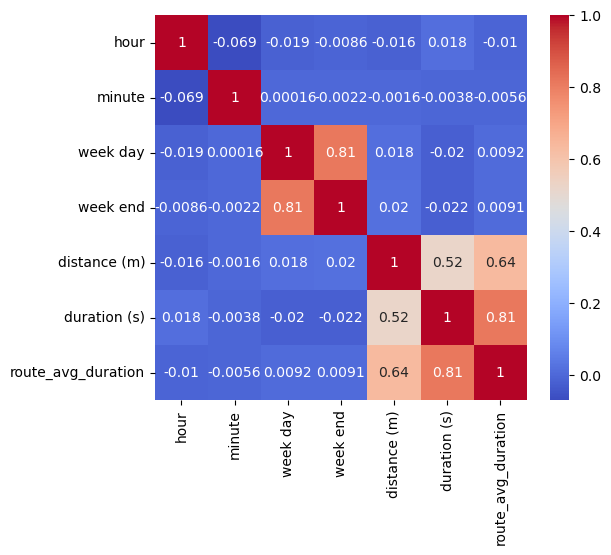

In [15]:
# duration
plt.figure(figsize=(8,5))
sns.histplot(df["duration (s)"], bins=50)
plt.title("Duration Distribution")
plt.show()

# duration vs distance
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="distance (m)",
    y="duration (s)",
    data=df
)
plt.show()

sns.boxplot(x="hour", y="duration (s)", data=df)
plt.xticks(rotation=45)
plt.show()

sns.boxplot(x="week end", y="duration (s)", data=df)
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [16]:
X = df.drop(columns=["duration (s)"])
Y = df["duration (s)"]

# categorical_cols = ["route"]
categorical_cols = ["start station", "end station"]
numeric_cols = ["distance (m)", "week day", "hour", "route_avg_duration"]
# numeric_cols = ["distance (m)", "week day", "hour", "weekend"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

In [17]:
linear_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, Y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
pred_lr = linear_model.predict(X_test)
print(pred_lr)

print("MAE:", mean_absolute_error(Y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, pred_lr)))
print("R2:", r2_score(Y_test, pred_lr))

[147.25380605 646.48169005 747.48428827 ... 706.37675831 215.337705
 896.44296601]
MAE: 87.95285709272676
RMSE: 180.03566560386156
R2: 0.6697892201166804


In [21]:
# Tạo ra file
joblib.dump(linear_model, "linear_regression_model.pkl")

['linear_regression_model.pkl']